In [1]:
import numpy as np
import glob
import lgdo.lh5 as lh5
import os, json
import copy
from pathlib import Path
import shutil
import glob
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pygama.pargen.utils import load_data
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
import pandas as pd
from tqdm.notebook import tqdm
import awkward as ak
import polars as pl

from helper_lib import *
from resolution_extraction import weighted_resolution_from_nested_dict as wres_full
from resolution_extraction import weighted_resolution_per_detector as wres_det
from resolution_extraction import weighted_value_per_det_type as wval_dtype
from resolution_extraction import weighted_resolution_per_detector_type as wres_dtype
from resolution_extraction import get_eres_per_detector
import resolution_extraction as rex

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"
# metadata2_path = os.environ["METADATA"]
metadata2_path = "/global/homes/b/borrfran/workspace/l200/legend-metadata"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']


meta = LegendMetadata(config['metadata'])
meta2 = LegendMetadata(metadata2_path)

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)
chmap_ak = ak.Array(chmap.group("system").geds.values())

DET_TYPES = ("BEGe", "COAX", "ICPC", "PPC")
DET_TYPE_MAP = {"B": "BEGe", "C": "COAX", "V": "ICPC", "P": "PPC"}

simulated_energies = list(range(200, 1100, 100))

outdir_name = "./v1/parquet/"
interaction = "dark-compton"
dictionaries_dir = "./v1/dictionaries"

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f5a8aba13a0>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f5a8aba14e0>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f5a8aba2b10>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f5a8aba2110>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f5a8abc97b0>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f5a8abcb650>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

# Popolate Parquet dataset from simulation

In [6]:
outdir_name = "dark-compton"

build_parquet_dataset(
    simulated_energies[3:],
    scratch_folder=scratch_folder,
    job_base="fromfile_dark_compton_{tag}_hpge_bulk",
    outdir_name="dark-compton",
    overwrite=True,
)

  0%|          | 0/6 [00:00<?, ?it/s]

# Read Parquet dataset

In [3]:
rawid_by_det_type = Props.read_from(f'{dictionaries_dir}/rawid_by_det_type.yaml')

In [4]:
lf = pl.scan_parquet(
    f"{outdir_name}/{interaction}",
    hive_partitioning=True
)

## Plot energy spectrum by detector type

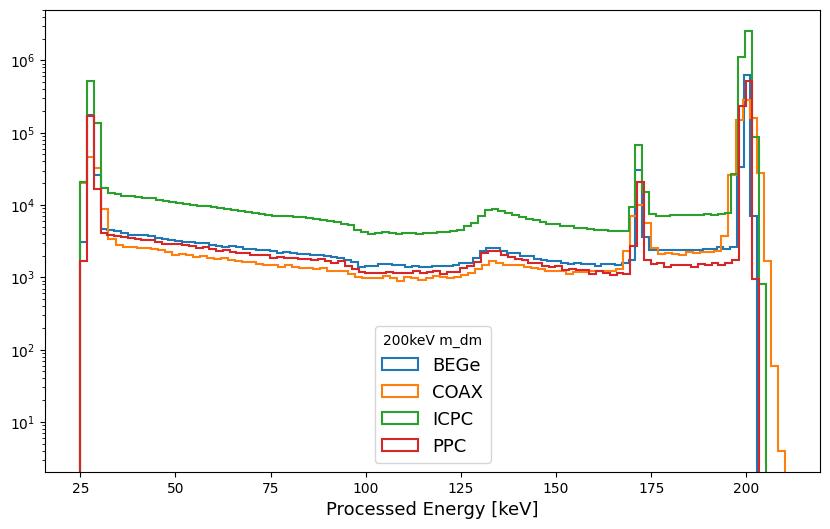

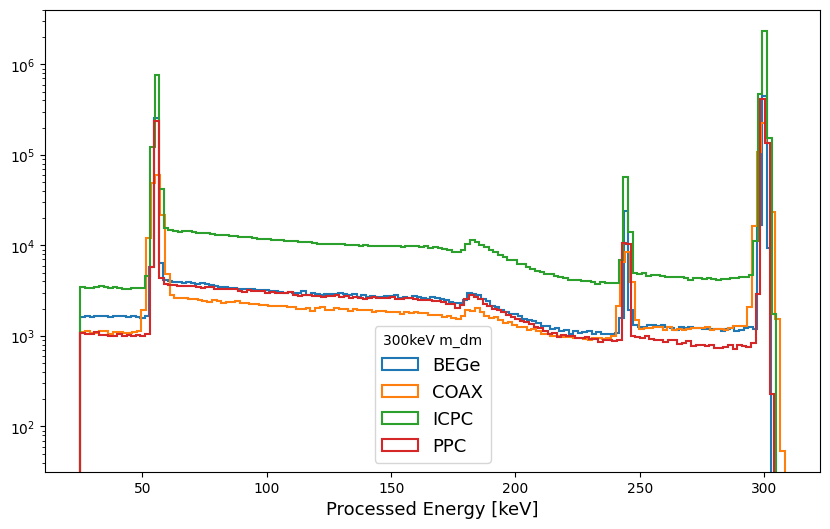

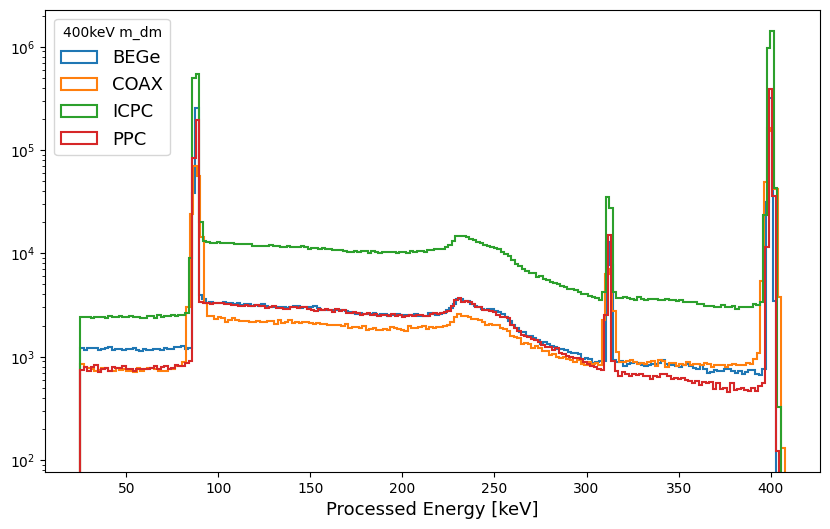

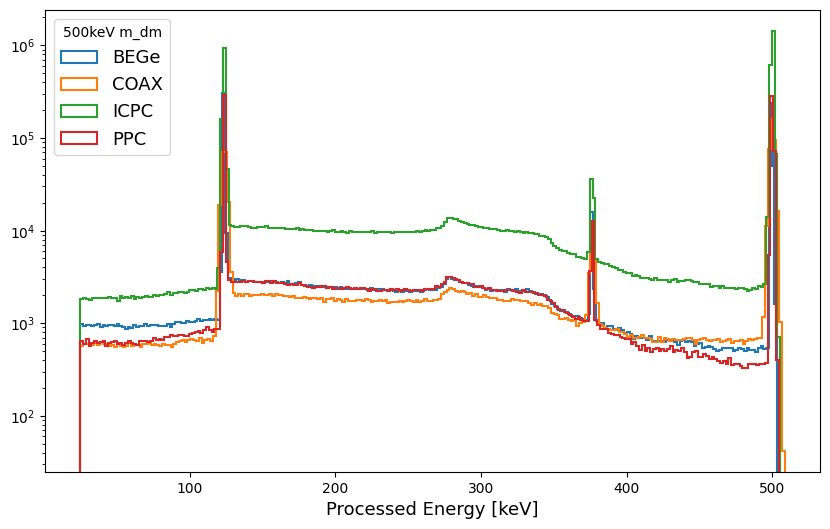

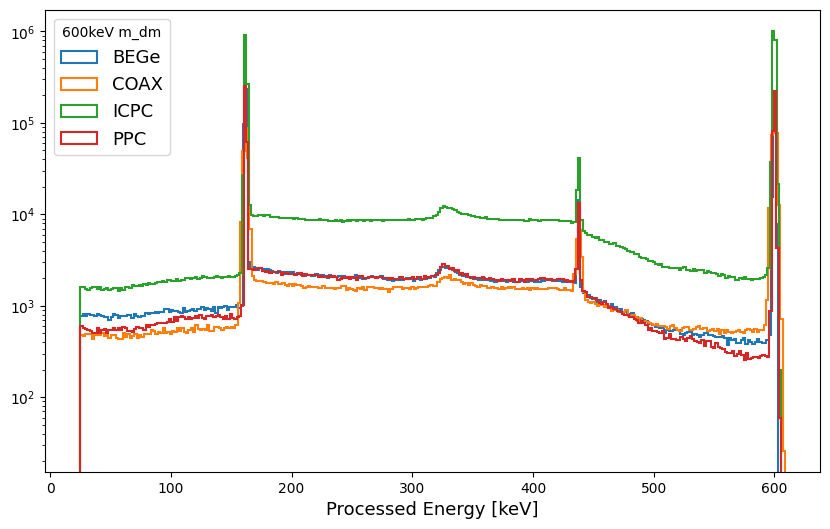

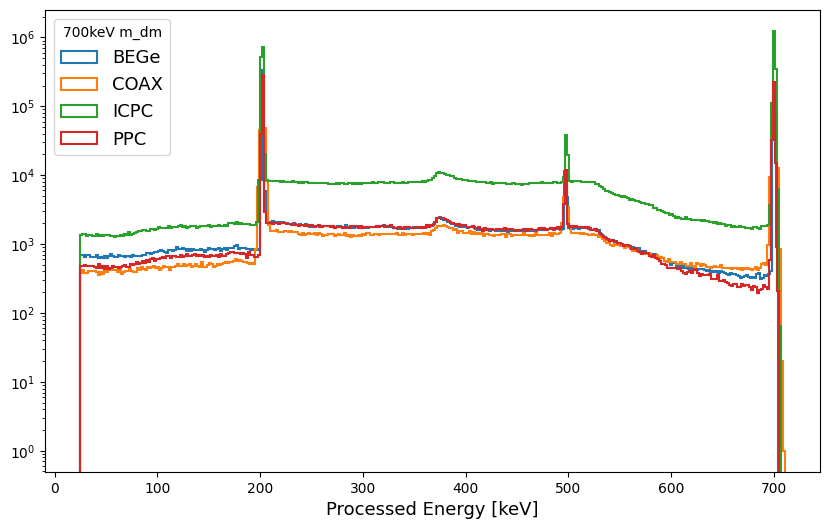

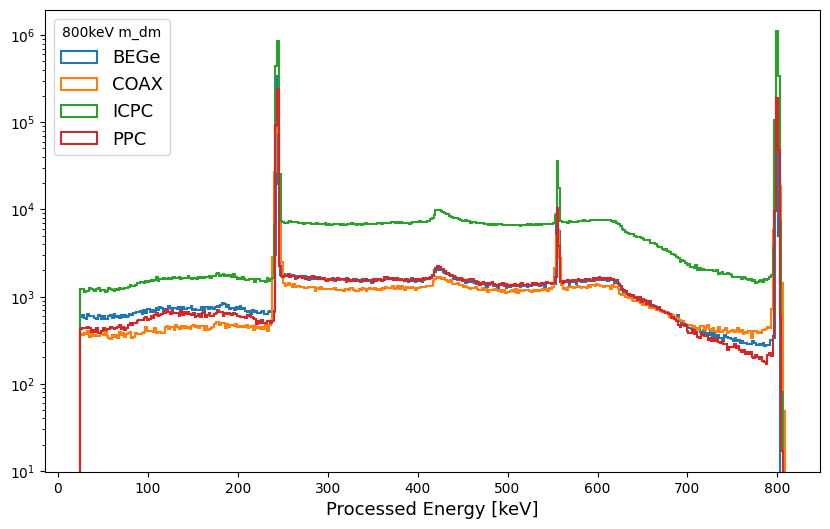

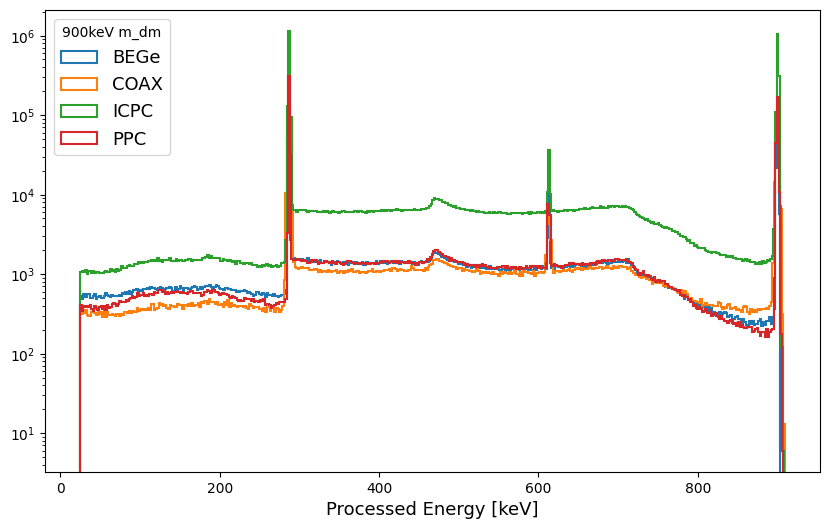

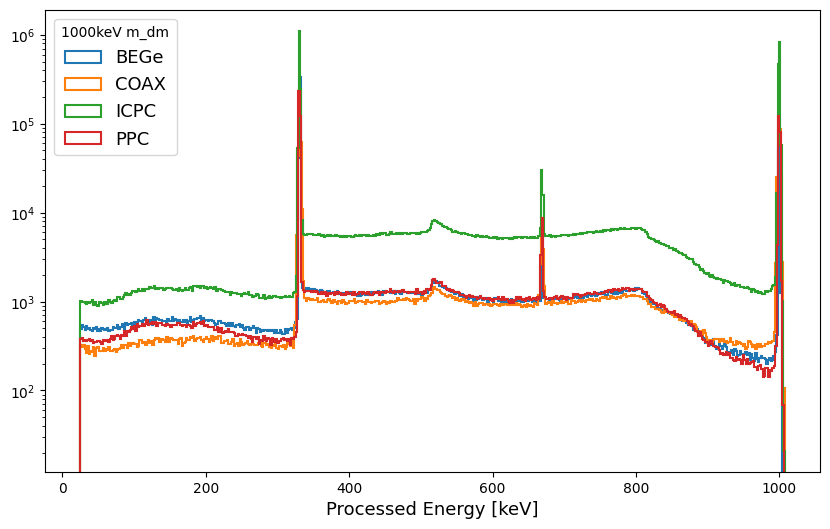

In [23]:
lw = 1.5
for ene in simulated_energies:
    
    plt.figure(figsize=(10, 6))
    
    for det_type in DET_TYPES:
        filtered_df = (
            lf.filter(
                (pl.col("sim_e") == ene) &
                pl.col("rawid").is_in(rawid_by_det_type[det_type])
            )
            .select([
                "energy"
            ])
            .collect()
        )
        
        plt.hist(filtered_df['energy'], bins=int(ene/2), label=det_type, histtype="step", linewidth=lw)

    plt.yscale("log")
    plt.legend(title=f"{ene}keV m_dm", fontsize=13)
    plt.xlabel("Processed Energy [keV]", fontsize=13)
    plt.savefig(f"./plots/{interaction}/det-type_energy-{ene}_{interaction}.png", dpi=300)
    plt.show()


## Compute fully contained efficiency

In [5]:
eres_dict = Props.read_from(f"{dictionaries_dir}/eres_per_det_tot.yaml")

In [7]:
ratio_dict = compute_efficiency_from_lazyframe(
    lf,
    eres_dict,
    simulated_energies,
    chmap,
)

  0%|          | 0/9 [00:00<?, ?it/s]

In [32]:
unc_list = []
ene_sim = 200
for key in ratio_dict[ene_sim]:
    if ratio_dict[ene_sim][key]['ratio_sigma'] > 0.0015:
        print(key)
    unc_list.append(ratio_dict[ene_sim][key]['ratio_sigma'])

B00035C
B00032B
B00091C
P00574B
P00698A
P00661B
P00574A
B00000B
B00000C
B00061A
B00061C
B00076C
B00079B
B00079C
V08682B
B00089C
V05261A
B00002A
B00089A
B00091A
P00538A
P00573A
P00662C
P00664A
P00909B
B00000D
B00002C
B00032C
B00032D
B00035A
B00035B
B00061B
B00089B
B00000A
B00002B
B00032A
P00573B
P00575A
P00574C
P00662A
P00662B
P00909C
P00661C
P00665C
P00748A


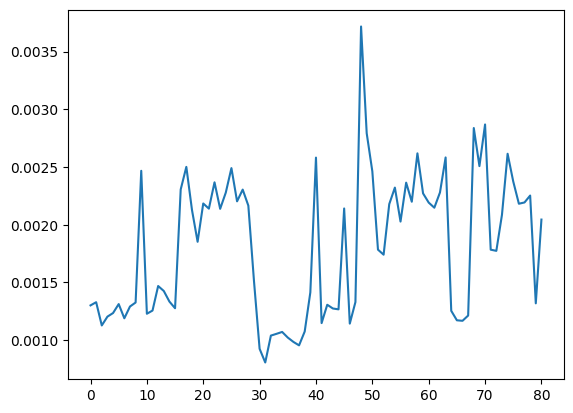

In [33]:
plt.plot(range(len(ratio_dict[1000].keys())), unc_list)

In [8]:
ratio_dict[200]['V02160A']

{'n_events': 85576,
 'n_primaries': 118618,
 'ratio': 0.7214400728382468,
 'ratio_sigma': 0.001301608845010853,
 'ratio_syst_fwhm': 1.2645528962462738e-05,
 'expo': 1.1298439995436915}

In [11]:
ratio_dict_means = get_mean_fcc_det_type(ratio_dict, key = "ratio", weight_key = "expo", unc_key= "ratio_sigma")


In [22]:
B = []
C = []
I = []
P = []

Bs = []
Cs = []
Is = []
Ps = []

for ene in ratio_dict_means.keys():

    B.append(ratio_dict_means[ene]['BEGe']['value'])
    I.append(ratio_dict_means[ene]['ICPC']['value'])
    C.append(ratio_dict_means[ene]['COAX']['value'])
    P.append(ratio_dict_means[ene]['PPC']['value'])
    
    Bs.append(ratio_dict_means[ene]['BEGe']['unc'])
    Is.append(ratio_dict_means[ene]['ICPC']['unc'])
    Cs.append(ratio_dict_means[ene]['COAX']['unc'])
    Ps.append(ratio_dict_means[ene]['PPC']['unc'])

B = np.array(B)
C = np.array(C)
I = np.array(I)
P = np.array(P)

Bs = np.array(Bs)
Cs = np.array(Cs)
Is = np.array(Is)
Ps = np.array(Ps)


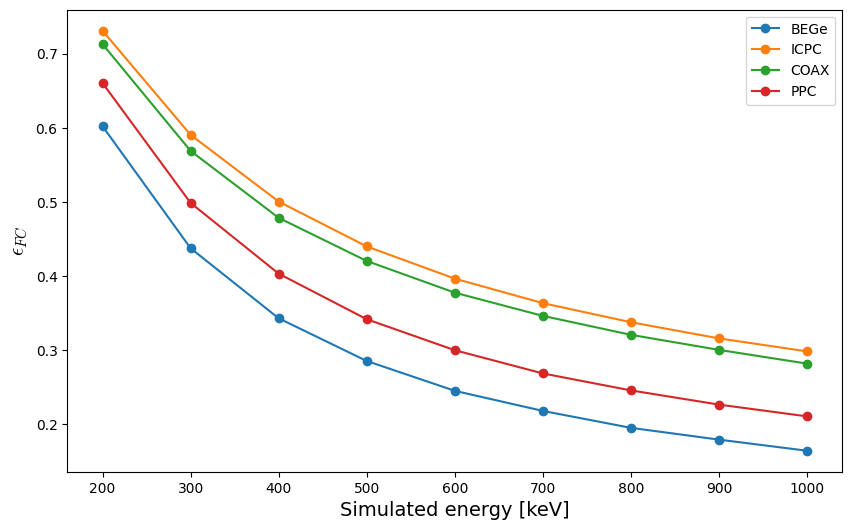

In [22]:
x = ratio_dict_means.keys()
plt.rcParams["mathtext.fontset"] = "cm"
plt.figure(figsize=(10,6))

plt.plot(x, B, marker = 'o', label = 'BEGe')
plt.plot(x, I, marker = 'o', label = 'ICPC')
plt.plot(x, C, marker = 'o', label = 'COAX')
plt.plot(x, P, marker = 'o', label = 'PPC')

plt.xlabel('Simulated energy [keV]', fontsize = 14)
plt.ylabel(r"$\epsilon_{FC}$", fontsize = 15)
plt.legend()
plt.savefig('./plots/dark-compton/FC-eff_det-type_dark-compton.png', dpi = 500)
plt.show()

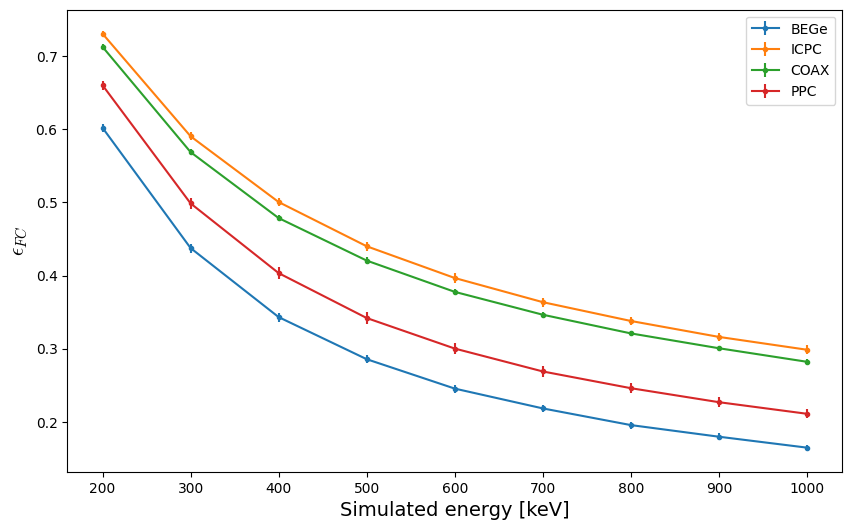

In [20]:
x = ratio_dict_means.keys()
plt.rcParams["mathtext.fontset"] = "cm"
plt.figure(figsize=(10,6))

plt.errorbar(x, B, yerr = Bs, marker = '.', label = 'BEGe')
plt.errorbar(x, I, yerr = Is, marker = '.', label = 'ICPC')
plt.errorbar(x, C, yerr = Cs, marker = '.', label = 'COAX')
plt.errorbar(x, P, yerr = Ps, marker = '.', label = 'PPC')

plt.xlabel('Simulated energy [keV]', fontsize = 14)
plt.ylabel(r"$\epsilon_{FC}$", fontsize = 15)
plt.legend()
plt.savefig('./plots/dark-compton/FC-eff_det-type_dark-compton.png', dpi = 500)
plt.show()

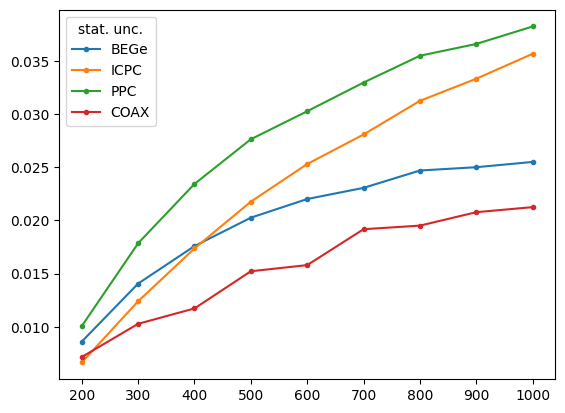

In [24]:
plt.errorbar(x, Bs/B, marker = '.', label = 'BEGe')
plt.errorbar(x, Is/B, marker = '.', label = 'ICPC')
plt.errorbar(x, Ps/B, marker = '.', label = 'PPC')
plt.errorbar(x, Cs/B, marker = '.', label = 'COAX')

plt.legend(title="stat. unc.")
plt.show()

In [25]:
print(Bs, B
    )

[0.00518197 0.00615294 0.00603499 0.0057845  0.00540046 0.00503325
 0.00482595 0.00448884 0.00419685] [0.60222932 0.43766931 0.34320118 0.28562832 0.24541144 0.21830805
 0.19549709 0.17958893 0.16463881]


  0%|          | 0/9 [00:00<?, ?it/s]

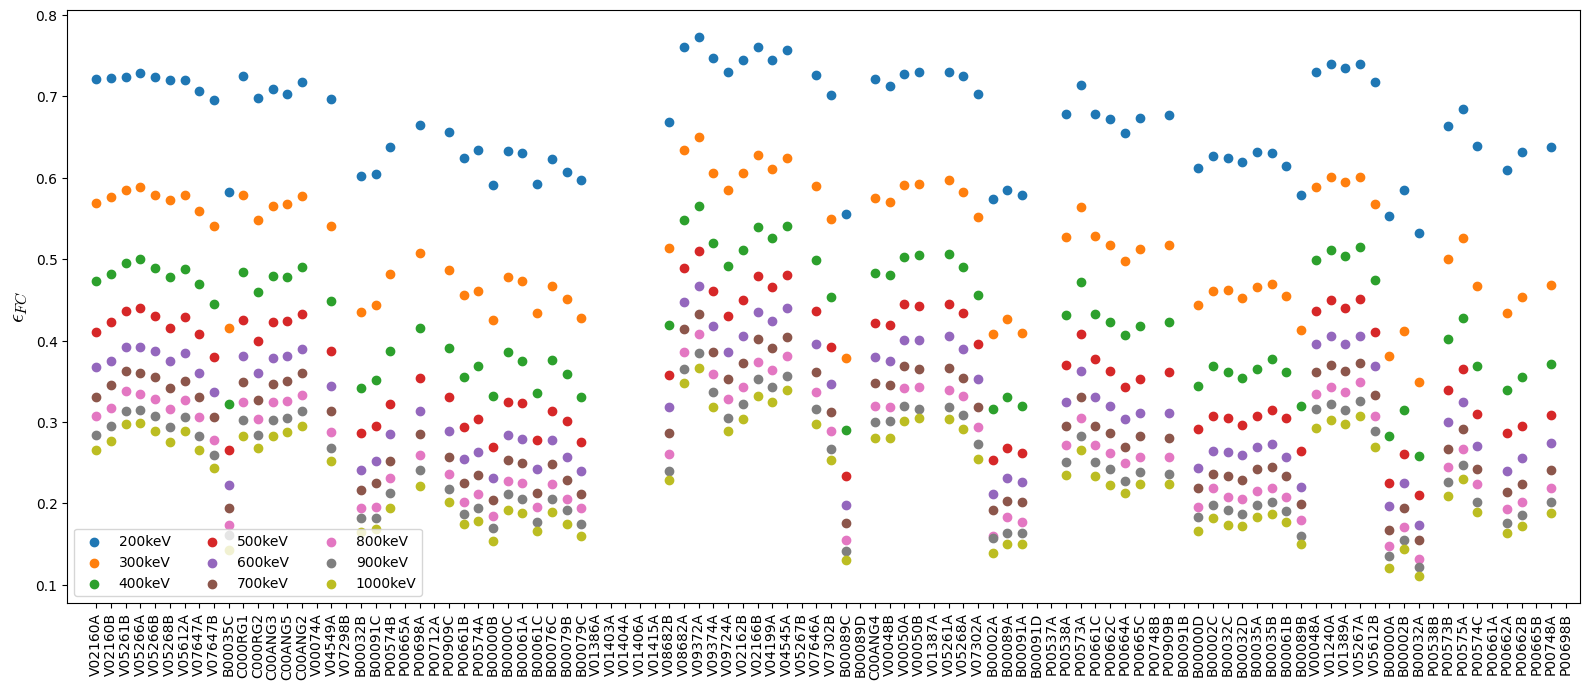

In [25]:
ges_sorted = chmap_ak.name

values_dict = {}

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(simulated_energies):
    
    keys, values = get_values_sorted(ratio_dict[ene], ges_sorted)
    tag = f'{ene}keV'
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel(r"$\epsilon_{FC}$", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3)
# Padding sotto per non tagliare le etichette
plt.tight_layout()
plt.savefig(f"./plots/{interaction}/FC-efficiency_{interaction}.png", dpi=500)
plt.show()
